In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/student_performance_prediction.csv")

In [ ]:
print("Raw Dataset Loaded Successfully")
print(df.head())

Raw Dataset Loaded Successfully
  Student ID  Study Hours per Week  Attendance Rate  Previous Grades  \
0     S00001                  12.5              NaN             75.0   
1     S00002                   9.3             95.3             60.6   
2     S00003                  13.2              NaN             64.0   
3     S00004                  17.6             76.8             62.4   
4     S00005                   8.8             89.3             72.7   

  Participation in Extracurricular Activities Parent Education Level Passed  
0                                         Yes                 Master    Yes  
1                                          No            High School     No  
2                                          No              Associate     No  
3                                         Yes               Bachelor     No  
4                                          No                 Master     No  


In [ ]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Student ID                                   11134 non-null  object 
 1   Study Hours per Week                         10593 non-null  float64
 2   Attendance Rate                              10560 non-null  float64
 3   Previous Grades                              10542 non-null  float64
 4   Participation in Extracurricular Activities  10612 non-null  object 
 5   Parent Education Level                       10575 non-null  object 
 6   Passed                                       10589 non-null  object 
dtypes: float64(3), object(4)
memory usage: 2.1+ MB
None


In [ ]:
print("Dataset Summary Statistics:")
print(df.describe())

Dataset Summary Statistics:
       study_hours_per_week  attendance_rate  previous_grades
count          11136.000000     11136.000000     11136.000000
mean               9.999093        75.418939        65.446668
std                4.922108        19.867818        16.224297
min               -9.600000       -10.900000        13.600000
25%                6.800000        62.800000        55.700000
50%               10.000000        75.400000        65.000000
75%               13.200000        88.000000        74.325000
max               29.600000       150.000000       200.000000


In [ ]:
print("\nDataset Shape:", df.shape)





Dataset Shape: (40000, 7)


In [ ]:
# 4. Check Missing Values
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())





Missing Values Before Cleaning:
Student ID                                     28866
Study Hours per Week                           29407
Attendance Rate                                29440
Previous Grades                                29458
Participation in Extracurricular Activities    29388
Parent Education Level                         29425
Passed                                         29411
dtype: int64


In [ ]:

# 5. Remove Duplicate Rows
df = df.drop_duplicates()
print("\nDuplicates Removed")


Duplicates Removed


In [ ]:
# 6. Handle Missing Values
for col in df.columns:
    # Numerical columns
    if df[col].dtype in ["int64", "float64"]:
        df[col] = df[col].fillna(df[col].median())
    # Categorical columns
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Handling:")
print(df.isnull().sum())


Missing Values After Handling:
Student ID                                     0
Study Hours per Week                           0
Attendance Rate                                0
Previous Grades                                0
Participation in Extracurricular Activities    0
Parent Education Level                         0
Passed                                         0
dtype: int64


In [ ]:
# 7. Clean Column Names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nCleaned Column Names:")
print(df.columns)


Cleaned Column Names:
Index(['student_id', 'study_hours_per_week', 'attendance_rate',
       'previous_grades', 'participation_in_extracurricular_activities',
       'parent_education_level', 'passed'],
      dtype='object')


In [ ]:
# 9. Final Dataset Check
print("\nFinal Dataset Info:")
print(df.info())
print("\nFinal Shape:", df.shape)


Final Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 11136 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   student_id                                   11136 non-null  object 
 1   study_hours_per_week                         11136 non-null  float64
 2   attendance_rate                              11136 non-null  float64
 3   previous_grades                              11136 non-null  float64
 4   participation_in_extracurricular_activities  11136 non-null  object 
 5   parent_education_level                       11136 non-null  object 
 6   passed                                       11136 non-null  object 
dtypes: float64(3), object(4)
memory usage: 696.0+ KB
None

Final Shape: (11136, 7)


In [ ]:
# 10. Save Cleaned Dataset
df.to_csv("student_performance_prediction_cleaned.csv", index=False)

print("\nCleaned dataset saved as 'student_performance_prediction_cleaned.csv'")


Cleaned dataset saved as 'student_performance_prediction_cleaned.csv'


In [ ]:
# ============================================
# ML Model Training Script
# Student Performance Prediction Project
# ============================================

# 1. Import Required Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
# 2. Load Cleaned Dataset
df = pd.read_csv("student_performance_prediction_cleaned.csv")

print("Cleaned Dataset Loaded Successfully")
print(df.head())


Cleaned Dataset Loaded Successfully
  student_id  study_hours_per_week  attendance_rate  previous_grades  \
0     S00001                  12.5             75.4             75.0   
1     S00002                   9.3             95.3             60.6   
2     S00003                  13.2             75.4             64.0   
3     S00004                  17.6             76.8             62.4   
4     S00005                   8.8             89.3             72.7   

  participation_in_extracurricular_activities parent_education_level passed  
0                                         Yes                 Master    Yes  
1                                          No            High School     No  
2                                          No              Associate     No  
3                                         Yes               Bachelor     No  
4                                          No                 Master     No  


In [ ]:

# 3. Separate Features (X) and Target (y)
X = df.drop("passed", axis=1)
y = df["passed"]

print("\nFeatures and Target separated")


Features and Target separated


In [ ]:
# 4. Encode Categorical Variables
X = pd.get_dummies(X, drop_first=True)

print("\nCategorical variables encoded")
print("Final feature shape:", X.shape)


Categorical variables encoded
Final feature shape: (11136, 11141)


In [ ]:
# 5. Split Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTrain-Test Split Completed")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Train-Test Split Completed
Training data: (8908, 11141)
Testing data: (2228, 11141)


In [ ]:
# 6. Initialize the ML Model
model = LogisticRegression(max_iter=1000)

In [ ]:

# 7. Train the Model
model.fit(X_train, y_train)

print("\nModel Training Completed Successfully")




Model Training Completed Successfully


In [ ]:
# 8. Make Predictions
y_pred = model.predict(X_test)


# 9. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Evaluation Results")
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Evaluation Results
Accuracy: 0.5448833034111311

Confusion Matrix:
[[  10 1010]
 [   4 1204]]

Classification Report:
              precision    recall  f1-score   support

          No       0.71      0.01      0.02      1020
         Yes       0.54      1.00      0.70      1208

    accuracy                           0.54      2228
   macro avg       0.63      0.50      0.36      2228
weighted avg       0.62      0.54      0.39      2228



In [ ]:
# 10. Predict for New Student (Sample Input)
new_student = pd.DataFrame({
    "study_hours_per_week": [12],
    "attendance_rate": [80],
    "previous_grades": [75],
    "participation_in_extracurricular_activities": ["Yes"],
    "parent_education_level": ["Graduate"]
})

# Encode new input same as training data
new_student = pd.get_dummies(new_student)
new_student = new_student.reindex(columns=X.columns, fill_value=0)

prediction = model.predict(new_student)

print("\nNew Student Prediction Result:")
if prediction[0] == 1:
    print("Student is likely to PASS")
else:
    print("Student is likely to FAIL")


New Student Prediction Result:
Student is likely to FAIL


Dataset Summary Statistics:
       study_hours_per_week  attendance_rate  previous_grades
count          11136.000000     11136.000000     11136.000000
mean               9.999093        75.418939        65.446668
std                4.922108        19.867818        16.224297
min               -9.600000       -10.900000        13.600000
25%                6.800000        62.800000        55.700000
50%               10.000000        75.400000        65.000000
75%               13.200000        88.000000        74.325000
max               29.600000       150.000000       200.000000

Target Variable Distribution (Passed):
passed
Yes    5928
No     5208
Name: count, dtype: int64


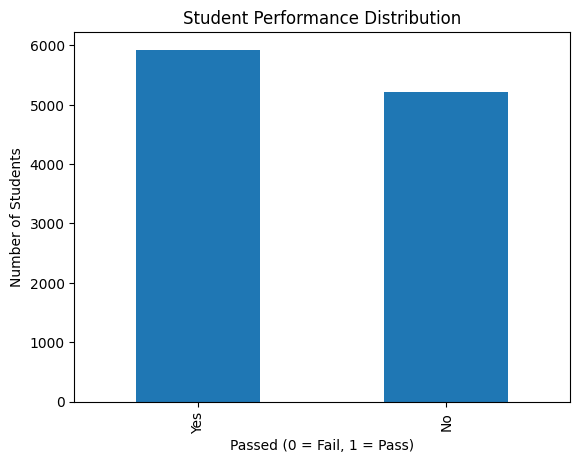

In [ ]:
# ============================================
# Result Analysis Script
# Student Performance Prediction Project
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load cleaned dataset
df = pd.read_csv("student_performance_prediction_cleaned.csv")

# Display basic statistics
print("Dataset Summary Statistics:")
print(df.describe())

# Target variable distribution
print("\nTarget Variable Distribution (Passed):")
print(df["passed"].value_counts())

# Plot Pass vs Fail distribution
plt.figure()
df["passed"].value_counts().plot(kind="bar")
plt.xlabel("Passed (0 = Fail, 1 = Pass)")
plt.ylabel("Number of Students")
plt.title("Student Performance Distribution")
plt.show()


In [ ]:
# =================================
# Demo Prediction for New Student
# PASS / FAIL Classification
# =================================

# Create demo dataset for 10 students
demo_students = pd.DataFrame({
    "study_hours_per_week": [5, 12, 8, 15, 3, 10, 18, 6, 14, 9],
    "attendance_rate": [60, 85, 70, 90, 50, 80, 95, 65, 88, 75],
    "previous_grades": [45, 78, 60, 85, 40, 70, 90, 55, 82, 68],
    "participation_in_extracurricular_activities": [
        "No", "Yes", "Yes", "Yes", "No",
        "Yes", "Yes", "No", "Yes", "Yes"
    ],
    "parent_education_level": [
        "High School", "Graduate", "Graduate", "Postgraduate", "High School",
        "Graduate", "Postgraduate", "High School", "Graduate", "Graduate"
    ]
})

# Encode categorical variables
demo_students_encoded = pd.get_dummies(demo_students)

# Align demo data with training features
demo_students_encoded = demo_students_encoded.reindex(
    columns=X.columns,
    fill_value=0
)

# Predict probabilities instead of direct class
demo_probabilities = model.predict_proba(demo_students_encoded)

# Set custom threshold
threshold = 0.53  # you can mention this in viva

# Convert probabilities to PASS / FAIL
demo_students["Prediction"] = [
    "PASS" if prob[1] >= threshold else "FAIL"
    for prob in demo_probabilities
]
demo_students["Pass_Probability"] = demo_probabilities[:, 1]
demo_students


,study_hours_per_week,attendance_rate,previous_grades,participation_in_extracurricular_activities,parent_education_level,Prediction,Pass_Probability
0,5,60,45,No,High School,PASS,0.540854
1,12,85,78,Yes,Graduate,FAIL,0.524307
2,8,70,60,Yes,Graduate,PASS,0.532207
3,15,90,85,Yes,Postgraduate,FAIL,0.518024
4,3,50,40,No,High School,PASS,0.545891
5,10,80,70,Yes,Graduate,FAIL,0.528096
6,18,95,90,Yes,Postgraduate,FAIL,0.511355
7,6,65,55,No,High School,PASS,0.539748
8,14,88,82,Yes,Graduate,FAIL,0.520040
9,9,75,68,Yes,Graduate,PASS,0.530720


In [ ]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))

In [ ]:
import pickle

# Save trained model
pickle.dump(model, open("model.pkl", "wb"))

print("model.pkl saved successfully")


model.pkl saved successfully
